In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from tqdm.notebook import tqdm  # Import tqdm specifically optimized for Jupyter

# 1. Load environment variables from your .env file
load_dotenv()
print("Connecting to PostgreSQL...")

# 2. Securely fetch the credentials
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

# 3. Construct the database URL and create the engine
db_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(db_url)

# 4. Ask PostgreSQL exactly how many rows exist so the progress bar knows what 100% is
count_query = "SELECT COUNT(*) FROM public.model_features_v06;"
total_rows = pd.read_sql(count_query, engine).iloc[0, 0]

# 5. Fetch the data in chunks and update the progress bar
query = "SELECT * FROM public.model_features_v06;"
chunksize = 100000 
chunks = [] # We will store our data chunks here temporarily

print(f"Fetching {total_rows:,} engineered features from local database...")

# Create the progress bar
with tqdm(total=total_rows, desc="Downloading Data") as pbar:
    # Read the data in chunks
    for chunk in pd.read_sql(query, engine, chunksize=chunksize):
        chunks.append(chunk)      # Save the chunk
        pbar.update(len(chunk))   # Move the progress bar forward

# 6. Stitch all the chunks together into one massive DataFrame
df = pd.concat(chunks, ignore_index=True)

print(f"Success! Loaded {len(df):,} rows into local memory.")
display(df.head())

Connecting to PostgreSQL...
Fetching 5,732,926 engineered features from local database...


Success! Loaded 5,732,926 rows into local memory.


,MONTH,DAY_OF_WEEK,AIRLINE_ID,ORIGIN_AIRPORT_ID,DESTINATION_AIRPORT_ID,DISTANCE,DEPARTURE_BLOCK,AIRLINE_HISTORIC_DELAY,ROUTE_HISTORIC_DELAY_BY_AIRLINE,ORIGIN_PRECIPITATION,...,ORIGIN_CLOUD_COVER_LOW,DEST_PRECIPITATION,DEST_SNOWFALL,DEST_WIND_SPEED,DEST_WIND_GUSTS,DEST_CLOUD_COVER_LOW,PREVIOUS_FLIGHT_DELAYED,ORIGIN_HOURLY_AIRPORT_TRAFFIC,DEST_HOURLY_AIRPORT_TRAFFIC,IS_DELAYED
0,11,5,9,86.0,278.0,1024,2,10.58,14.33,0.0,...,0,0.0,0.0,9.7,18.4,0,0,37,14,1
1,11,1,2,177.0,23.0,1242,1,8.90,6.27,0.0,...,87,0.0,0.0,2.9,13.7,0,0,34,10,0
2,7,2,2,23.0,177.0,1242,2,8.90,8.15,0.0,...,2,0.0,0.0,5.4,14.0,98,0,9,28,0
3,7,5,2,23.0,177.0,1242,3,8.90,8.15,0.0,...,0,0.0,0.0,16.5,36.7,36,0,7,57,0
4,9,7,2,23.0,177.0,1242,3,8.90,8.15,0.0,...,0,0.0,0.0,10.5,29.2,0,0,2,48,0


In [5]:
from sklearn.model_selection import train_test_split
import cupy as cp

print("Starting preprocessing...")

# 1. Drop columns we don't need for the predictive model
# relying on the ROUTE_HISTORIC_DELAY feature instead.
columns_to_drop = ['MONTH', 'DAY_OF_WEEK']
df_clean = df.drop(columns=columns_to_drop)

# 3. Separate your Features (X) from your Target (y)
X = df_clean.drop(columns=['IS_DELAYED'])
y = df_clean['IS_DELAYED']

# 4. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert once, right after your train/test split — not inside the objective function
X_train_gpu = cp.array(X_train.values if hasattr(X_train, 'values') else X_train)
y_train_gpu = cp.array(y_train.values if hasattr(y_train, 'values') else y_train)

print("Preprocessing complete!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Starting preprocessing...
Preprocessing complete!
Training features shape: (4586340, 20)
Testing features shape: (1146586, 20)


In [6]:
from xgboost import XGBClassifier
import time

print("Initializing XGBoost Classifier...")
# We use standard default parameters to establish a strong baseline
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss' # Tells the model how to measure its own errors during training
)

print("Training the model on 80% of the data. Please wait...")
start_time = time.time()

# This single line is where the actual math and "learning" happens
model.fit(X_train, y_train)

end_time = time.time()
print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Initializing XGBoost Classifier...
Training the model on 80% of the data. Please wait...
Success! Training complete in 16.29 seconds.


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_v06_v00.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92    942296
           1       0.70      0.41      0.51    204290

    accuracy                           0.86   1146586
   macro avg       0.79      0.68      0.72   1146586
weighted avg       0.85      0.86      0.85   1146586

--- Confusion Matrix ---
[[906049  36247]
 [121462  82828]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_v06_v00.joblib


In [8]:
from xgboost import XGBClassifier
import time

print("Calculating class imbalance...")
# Count the 0s (On Time) and divide by the 1s (Delayed)
# Based on your confusion matrix, this will be roughly 4.6
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Imbalance Ratio: {round(imbalance_ratio, 2)} to 1")

print("\nInitializing Tuned XGBoost Classifier...")
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio  # <-- The magic parameter
)

print("Training the model. Please wait...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Calculating class imbalance...
Imbalance Ratio: 4.63 to 1

Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 15.0 seconds.


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_v06_v01.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.84      0.87    942296
           1       0.45      0.61      0.52    204290

    accuracy                           0.80   1146586
   macro avg       0.68      0.73      0.70   1146586
weighted avg       0.83      0.80      0.81   1146586

--- Confusion Matrix ---
[[788740 153556]
 [ 78799 125491]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_v06_v01.joblib


In [10]:
from xgboost import XGBClassifier
import time

print("\nInitializing Tuned XGBoost Classifier...")
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    max_depth = 3,
    learning_rate = 0.01
)

print("Training the model. Please wait...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")


Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 11.52 seconds.


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = 'xgboost_delay_model_v06_v02.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.99      0.91    942296
           1       0.75      0.20      0.32    204290

    accuracy                           0.85   1146586
   macro avg       0.80      0.59      0.61   1146586
weighted avg       0.83      0.85      0.81   1146586

--- Confusion Matrix ---
[[928588  13708]
 [163535  40755]]

Boom! Model fully trained, evaluated, and saved locally as: xgboost_delay_model_v06_v02.joblib


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import time
import joblib

print("1. Calculating class imbalance for the safety net...")
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("2. Constructing the Master Parameter Grid...")
param_grid = {
    # --- 1. Tree Architecture (Complexity) ---
    'max_depth': [3, 4, 5, 6, 7],           # How deep to grow (7 is pushing it!)
    'gamma': [0, 1, 5],                     # Minimum loss reduction required to split a node
    
    # --- 2. Optimization Dynamics (Speed vs Stamina) ---
    'learning_rate': [0.01, 0.05, 0.1, 0.2],# Step size
    'n_estimators': [100, 200, 300, 500],   # Number of trees (Stamina)
    
    # --- 3. Randomization (Noise Protection) ---
    'subsample': [0.6, 0.8, 1.0],           # % of rows used per tree
    'colsample_bytree': [0.6, 0.8, 1.0],    # % of columns used per tree
    
    # --- 4. Regularization (Mathematical Penalties for Overfitting) ---
    'reg_alpha': [0, 0.1, 1],               # L1 penalty (encourages dropping useless features)
    'reg_lambda': [1, 10, 100]              # L2 penalty (prevents weights from getting too large)
}

print("3. Initializing the Base Engine...")
# We lock the random state for reproducibility and load our crucial imbalance ratio
xgb_base = XGBClassifier(
    random_state=42, 
    eval_metric='logloss', 
    scale_pos_weight=imbalance_ratio
)

print("4. Configuring the Randomized Search...")
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,         # Test 10 distinct, random combinations from the grid above
    scoring='f1',      # The compass: find the best balance of Precision and Recall
    cv=3,              # 3-Fold Cross Validation (Tests each combo 3 times on different data slices)
    verbose=2,         # Prints live progress so you know it hasn't frozen
    random_state=42,
    n_jobs=-1          # -1 tells Python to use 100% of your available CPU cores
)

print("5. Commencing Model Training (Grab a coffee, let the machine sweat)...")
start_time = time.time()

# The actual heavy lifting
random_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nSuccess! Tuning complete in {round((end_time - start_time)/60, 2)} minutes.")

print("\n======================================")
print("🏆 THE CHAMPION PARAMETERS 🏆")
print("======================================")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

# Save the absolute best version of the model to your hard drive
best_model = random_search.best_estimator_
model_filename = 'xgboost_delay_model_ULTIMATE_v06.joblib'
joblib.dump(best_model, model_filename)

print(f"\nFinal model compiled and saved as: {model_filename}")

1. Calculating class imbalance for the safety net...
2. Constructing the Master Parameter Grid...
3. Initializing the Base Engine...
4. Configuring the Randomized Search...
5. Commencing Model Training (Grab a coffee, let the machine sweat)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Success! Tuning complete in 15.2 minutes.

🏆 THE CHAMPION PARAMETERS 🏆
subsample: 1.0
reg_lambda: 10
reg_alpha: 0
n_estimators: 300
max_depth: 6
learning_rate: 0.1
gamma: 0
colsample_bytree: 1.0

Final model compiled and saved as: xgboost_delay_model_ULTIMATE_v05.joblib


In [ ]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix

print("Loading the Ultimate Champion Model from disk...")
# We load the .joblib file we saved in the last step
final_model = joblib.load('xgboost_delay_model_ULTIMATE_v06.joblib')

print("Evaluating the model on the hidden test data...")
# Ask the champion to make its predictions
y_pred_final = final_model.predict(X_test)

# Print the ultimate KPIs
print("\n🏆 --- FINAL CLASSIFICATION REPORT --- 🏆")
print(classification_report(y_test, y_pred_final))

print("🏆 --- FINAL CONFUSION MATRIX --- 🏆")
print(confusion_matrix(y_test, y_pred_final))

Loading the Ultimate Champion Model from disk...
Evaluating the model on the hidden test data...

🏆 --- FINAL CLASSIFICATION REPORT --- 🏆
              precision    recall  f1-score   support

           0       0.91      0.84      0.87    942296
           1       0.45      0.61      0.52    204290

    accuracy                           0.80   1146586
   macro avg       0.68      0.73      0.70   1146586
weighted avg       0.83      0.80      0.81   1146586

🏆 --- FINAL CONFUSION MATRIX --- 🏆
[[790490 151806]
 [ 78931 125359]]


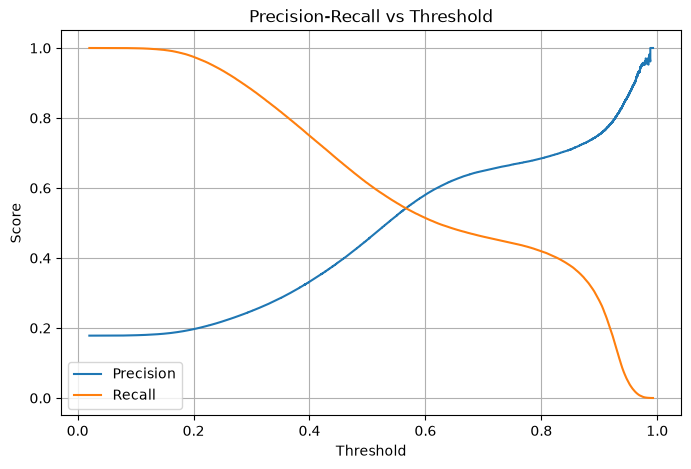

Best threshold for F1: 0.613
At this threshold -> Precision: 0.594, Recall: 0.505, F1: 0.546
              precision    recall  f1-score   support

           0       0.90      0.93      0.91    942296
           1       0.59      0.50      0.55    204290

    accuracy                           0.85   1146586
   macro avg       0.75      0.72      0.73   1146586
weighted avg       0.84      0.85      0.85   1146586

[[871822  70474]
 [101152 103138]]


In [5]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Get PROBABILITIES instead of hard predictions
y_proba = final_model.predict_proba(X_test)[:, 1]  # probability of class 1 (delayed)

# 2. Compute precision/recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# 3. Plot it so you can SEE the tradeoff
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.grid(True)
plt.show()

# 4. Find the threshold that MAXIMIZES F1 (a good starting default)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold for F1: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

# 5. Apply your chosen threshold to get new predictions
y_pred_tuned = (y_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

In [9]:
import numpy as np

# Check a handful of thresholds around the crossover zone
for t in [0.3, 0.4, 0.45, 0.5, 0.55, 0.613, 0.65, 0.7]:
    y_pred_t = (y_proba >= t).astype(int)
    p = precisions[np.argmin(np.abs(thresholds - t))]
    r = recalls[np.argmin(np.abs(thresholds - t))]
    print(f"Threshold {t:.2f} -> Precision: {p:.3f}, Recall: {r:.3f}")

Threshold 0.30 -> Precision: 0.249, Recall: 0.881
Threshold 0.40 -> Precision: 0.332, Recall: 0.749
Threshold 0.45 -> Precision: 0.388, Recall: 0.680
Threshold 0.50 -> Precision: 0.452, Recall: 0.614
Threshold 0.55 -> Precision: 0.521, Recall: 0.558
Threshold 0.61 -> Precision: 0.594, Recall: 0.505
Threshold 0.65 -> Precision: 0.623, Recall: 0.483
Threshold 0.70 -> Precision: 0.649, Recall: 0.461


In [13]:
import os
import warnings
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Silence the DMatrix fallback warning (harmless, just a minor overhead notice)
warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')

print("1. Calculating class imbalance for the safety net...")
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 100, log=True),
    }
    model = XGBClassifier(
        **params,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=imbalance_ratio,
        tree_method='hist',
        device='cuda'
    )
    # Plain pandas X_train / y_train — no cupy
    score = cross_val_score(model, X_train, y_train, scoring='f1', cv=3, n_jobs=1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

best_model = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio,
    tree_method='hist',
    device='cuda'
)
best_model.fit(X_train, y_train)

import joblib
joblib.dump(best_model, 'xgboost_delay_model_v06.joblib')

[I 2026-07-07 00:38:24,987] A new study created in memory with name: no-name-4b4cf7c9-662b-4dc4-b7a9-383533392c23


1. Calculating class imbalance for the safety net...


[I 2026-07-07 00:38:52,103] Trial 0 finished with value: 0.513766539640221 and parameters: {'max_depth': 3, 'gamma': 1.4491658680619812, 'learning_rate': 0.179265237865667, 'n_estimators': 483, 'subsample': 0.6570245840334552, 'colsample_bytree': 0.5880328068838003, 'reg_alpha': 0.04181726032340416, 'reg_lambda': 0.532797142718246}. Best is trial 0 with value: 0.513766539640221.
[I 2026-07-07 00:39:18,621] Trial 1 finished with value: 0.5150698485924963 and parameters: {'max_depth': 5, 'gamma': 1.0817064242979875, 'learning_rate': 0.056941057019045636, 'n_estimators': 353, 'subsample': 0.7320814644701334, 'colsample_bytree': 0.9783540315809007, 'reg_alpha': 0.3799503697118427, 'reg_lambda': 41.15625268656244}. Best is trial 1 with value: 0.5150698485924963.
[I 2026-07-07 00:39:33,570] Trial 2 finished with value: 0.5148482619299549 and parameters: {'max_depth': 5, 'gamma': 0.5335215697424833, 'learning_rate': 0.24609411214402258, 'n_estimators': 101, 'subsample': 0.8283861966844737, 'c

Best F1: 0.5309526196837263
Best params: {'max_depth': 9, 'gamma': 0.33956175021067253, 'learning_rate': 0.17385225395093715, 'n_estimators': 407, 'subsample': 0.9616376732053606, 'colsample_bytree': 0.8739618275008552, 'reg_alpha': 0.7463707811103573, 'reg_lambda': 17.160938620634102}


['xgboost_delay_model_v06.joblib']

In [14]:
import joblib
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

best_model = joblib.load('xgboost_delay_model_v06.joblib')
y_proba = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Best threshold: 0.615
Precision: 0.598, Recall: 0.519, F1: 0.556
              precision    recall  f1-score   support

           0       0.90      0.92      0.91    942296
           1       0.60      0.52      0.56    204290

    accuracy                           0.85   1146586
   macro avg       0.75      0.72      0.73   1146586
weighted avg       0.85      0.85      0.85   1146586

[[871081  71215]
 [ 98224 106066]]


PREVIOUS_FLIGHT_DELAYED            0.819720
DEPARTURE_BLOCK                    0.020743
ORIGIN_SNOWFALL                    0.020428
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.017901
AIRLINE_HISTORIC_DELAY             0.016428
ORIGIN_PRECIPITATION               0.014648
DEST_SNOWFALL                      0.014041
DEST_PRECIPITATION                 0.009147
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.008553
AIRLINE_ID                         0.006994
ORIGIN_AIRPORT_ID                  0.006525
DEST_HOURLY_AIRPORT_TRAFFIC        0.005754
ORIGIN_CLOUD_COVER_LOW             0.005689
DISTANCE                           0.005587
DEST_CLOUD_COVER_LOW               0.005553
DESTINATION_AIRPORT_ID             0.005460
ORIGIN_WIND_GUSTS                  0.004549
DEST_WIND_GUSTS                    0.004250
ORIGIN_WIND_SPEED                  0.004100
DEST_WIND_SPEED                    0.003930
dtype: float32


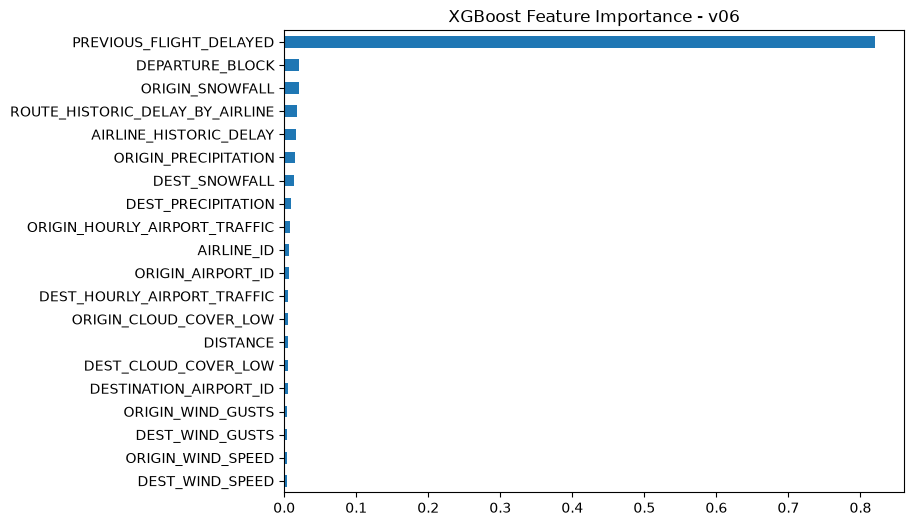

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v06')
plt.gca().invert_yaxis()
plt.show()

In [16]:
# How is PREVIOUS_FLIGHT_DELAYED distributed? 
print(X_train['PREVIOUS_FLIGHT_DELAYED'].value_counts(dropna=False))

# Check correlation strength - is it almost perfectly predictive, or just strongly predictive?
print(pd.crosstab(X_train['PREVIOUS_FLIGHT_DELAYED'], y_train, normalize='index'))

PREVIOUS_FLIGHT_DELAYED
0    4047794
1     538546
Name: count, dtype: int64
IS_DELAYED                      0         1
PREVIOUS_FLIGHT_DELAYED                    
0                        0.886278  0.113722
1                        0.342780  0.657220


In [17]:
X_train['PREVIOUS_FLIGHT_DELAYED'].isnull().sum()

np.int64(0)